# Breast Cancer Prediction using Supervised Machine Learning

## Minor Project

**Student Name:** Mohd Aatir

**Objective:**  
To develop a supervised machine learning model that predicts whether a breast tumor is **Benign** or **Malignant** using diagnostic measurements.

---

## 1. Importing Required Libraries

Before working with the dataset, we need to import the Python libraries required for data manipulation, visualization, and machine learning.

In [1]:
# STEP 1: Import Required Libraries

# Numerical computations
import numpy as np

# Data manipulation and analysis
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt

# Machine Learning library
import sklearn

## 2. Loading the Dataset

In this section, we will load the Breast Cancer dataset into a Pandas DataFrame. A DataFrame is a two-dimensional table consisting of rows and columns, making it easy to analyze and manipulate data.

In [2]:
# STEP 2: Load the Dataset

import pandas as pd

df = pd.read_csv("../data/dataset.csv")

df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


## 3. Understanding the Dataset

Before preprocessing the data, it is important to understand its structure, dimensions, data types, and identify any missing values. This helps in planning the necessary preprocessing steps.

In [3]:
# STEP 3: Understanding the Dataset

# Display the number of rows and columns
print("Shape of the dataset:")
print(df.shape)

print("\n")

# Display column names
print("Column Names:")
print(df.columns)

print("\n")

# Display information about the dataset
print("Dataset Information:")
df.info()

print("\n")

# Display statistical summary
print("Statistical Summary:")
display(df.describe())

Shape of the dataset:
(569, 33)


Column Names:
Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='str')


Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagno

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


## 4. Data Preprocessing

Raw datasets often contain unnecessary columns, missing values, duplicate records, or categorical data that cannot be directly used by machine learning algorithms. In this section, the dataset is cleaned and transformed to make it suitable for model training.

In [4]:
# STEP 4.1: Remove Unnecessary Columns

# Remove the 'Unnamed: 32' column because it contains only missing values
df.drop(columns=["Unnamed: 32"], inplace=True)

# Remove the 'id' column because it is only a unique identifier
df.drop(columns=["id"], inplace=True)

# Display the first five rows after removing columns
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [5]:
# Check the new shape of the dataset
print("New Shape:", df.shape)

print("\nUpdated Columns:\n")
print(df.columns)

New Shape: (569, 31)

Updated Columns:

Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='str')


### 4.2 Checking Missing Values

Missing values can negatively affect the performance of machine learning models. Therefore, it is important to identify whether the dataset contains any missing values before proceeding further.

In [6]:
# STEP 4.2: Check Missing Values

# Count missing values in each column
missing_values = df.isnull().sum()

print("Missing Values in Each Column:")
print(missing_values)

print("\nTotal Missing Values:", missing_values.sum())

Missing Values in Each Column:
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

Total Missing Values: 0


### 4.3 Checking Duplicate Records

Duplicate records can introduce bias into the machine learning model. Therefore, the dataset is checked for duplicate entries.

In [7]:
# STEP 4.3: Check Duplicate Records

duplicates = df.duplicated().sum()

print("Total Duplicate Records:", duplicates)

Total Duplicate Records: 0


### 4.4 Encoding the Target Variable

The target variable **diagnosis** contains categorical values (**M** for Malignant and **B** for Benign). Machine learning algorithms require numerical input; therefore, these values are encoded into numeric form.

In [8]:
# STEP 4.4: Encode the Target Variable

# Display unique values before encoding
print("Before Encoding:")
print(df["diagnosis"].value_counts())

# Encode diagnosis column
df["diagnosis"] = df["diagnosis"].map({
    "M": 1,
    "B": 0
})

print("\nAfter Encoding:")
print(df["diagnosis"].value_counts())

print("\nSample Data:")
df.head()

Before Encoding:
diagnosis
B    357
M    212
Name: count, dtype: int64

After Encoding:
diagnosis
0    357
1    212
Name: count, dtype: int64

Sample Data:


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


# 5. Exploratory Data Analysis (EDA)

## 5.1 Class Distribution

### Objective

The first step of exploratory data analysis is to examine the distribution of the target variable (**diagnosis**). This helps determine whether the dataset is balanced or imbalanced.

Class Distribution:
diagnosis
0    357
1    212
Name: count, dtype: int64


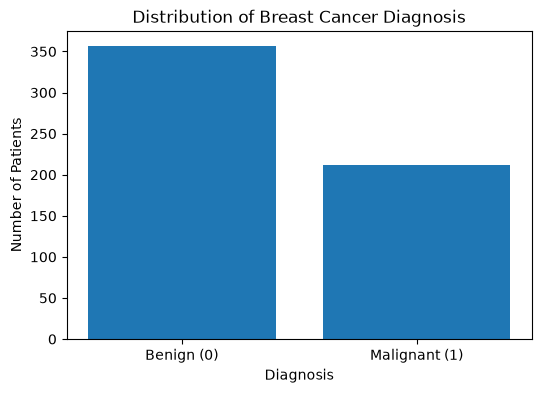

In [9]:
#STEP 5.1: Class Distribution

# Count each class
class_counts = df["diagnosis"].value_counts()

print("Class Distribution:")
print(class_counts)

# Plot bar chart
plt.figure(figsize=(6,4))

plt.bar(
    ["Benign (0)", "Malignant (1)"],
    class_counts.sort_index(),
)

plt.title("Distribution of Breast Cancer Diagnosis")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Patients")

import os
os.makedirs("results", exist_ok=True)

plt.savefig(
    "../results/class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 5.2 Distribution of Numerical Features

### Objective

Histograms are used to visualize the distribution of numerical features. They help identify whether the data follows a normal distribution, is skewed, or contains unusual patterns that may affect machine learning model performance.

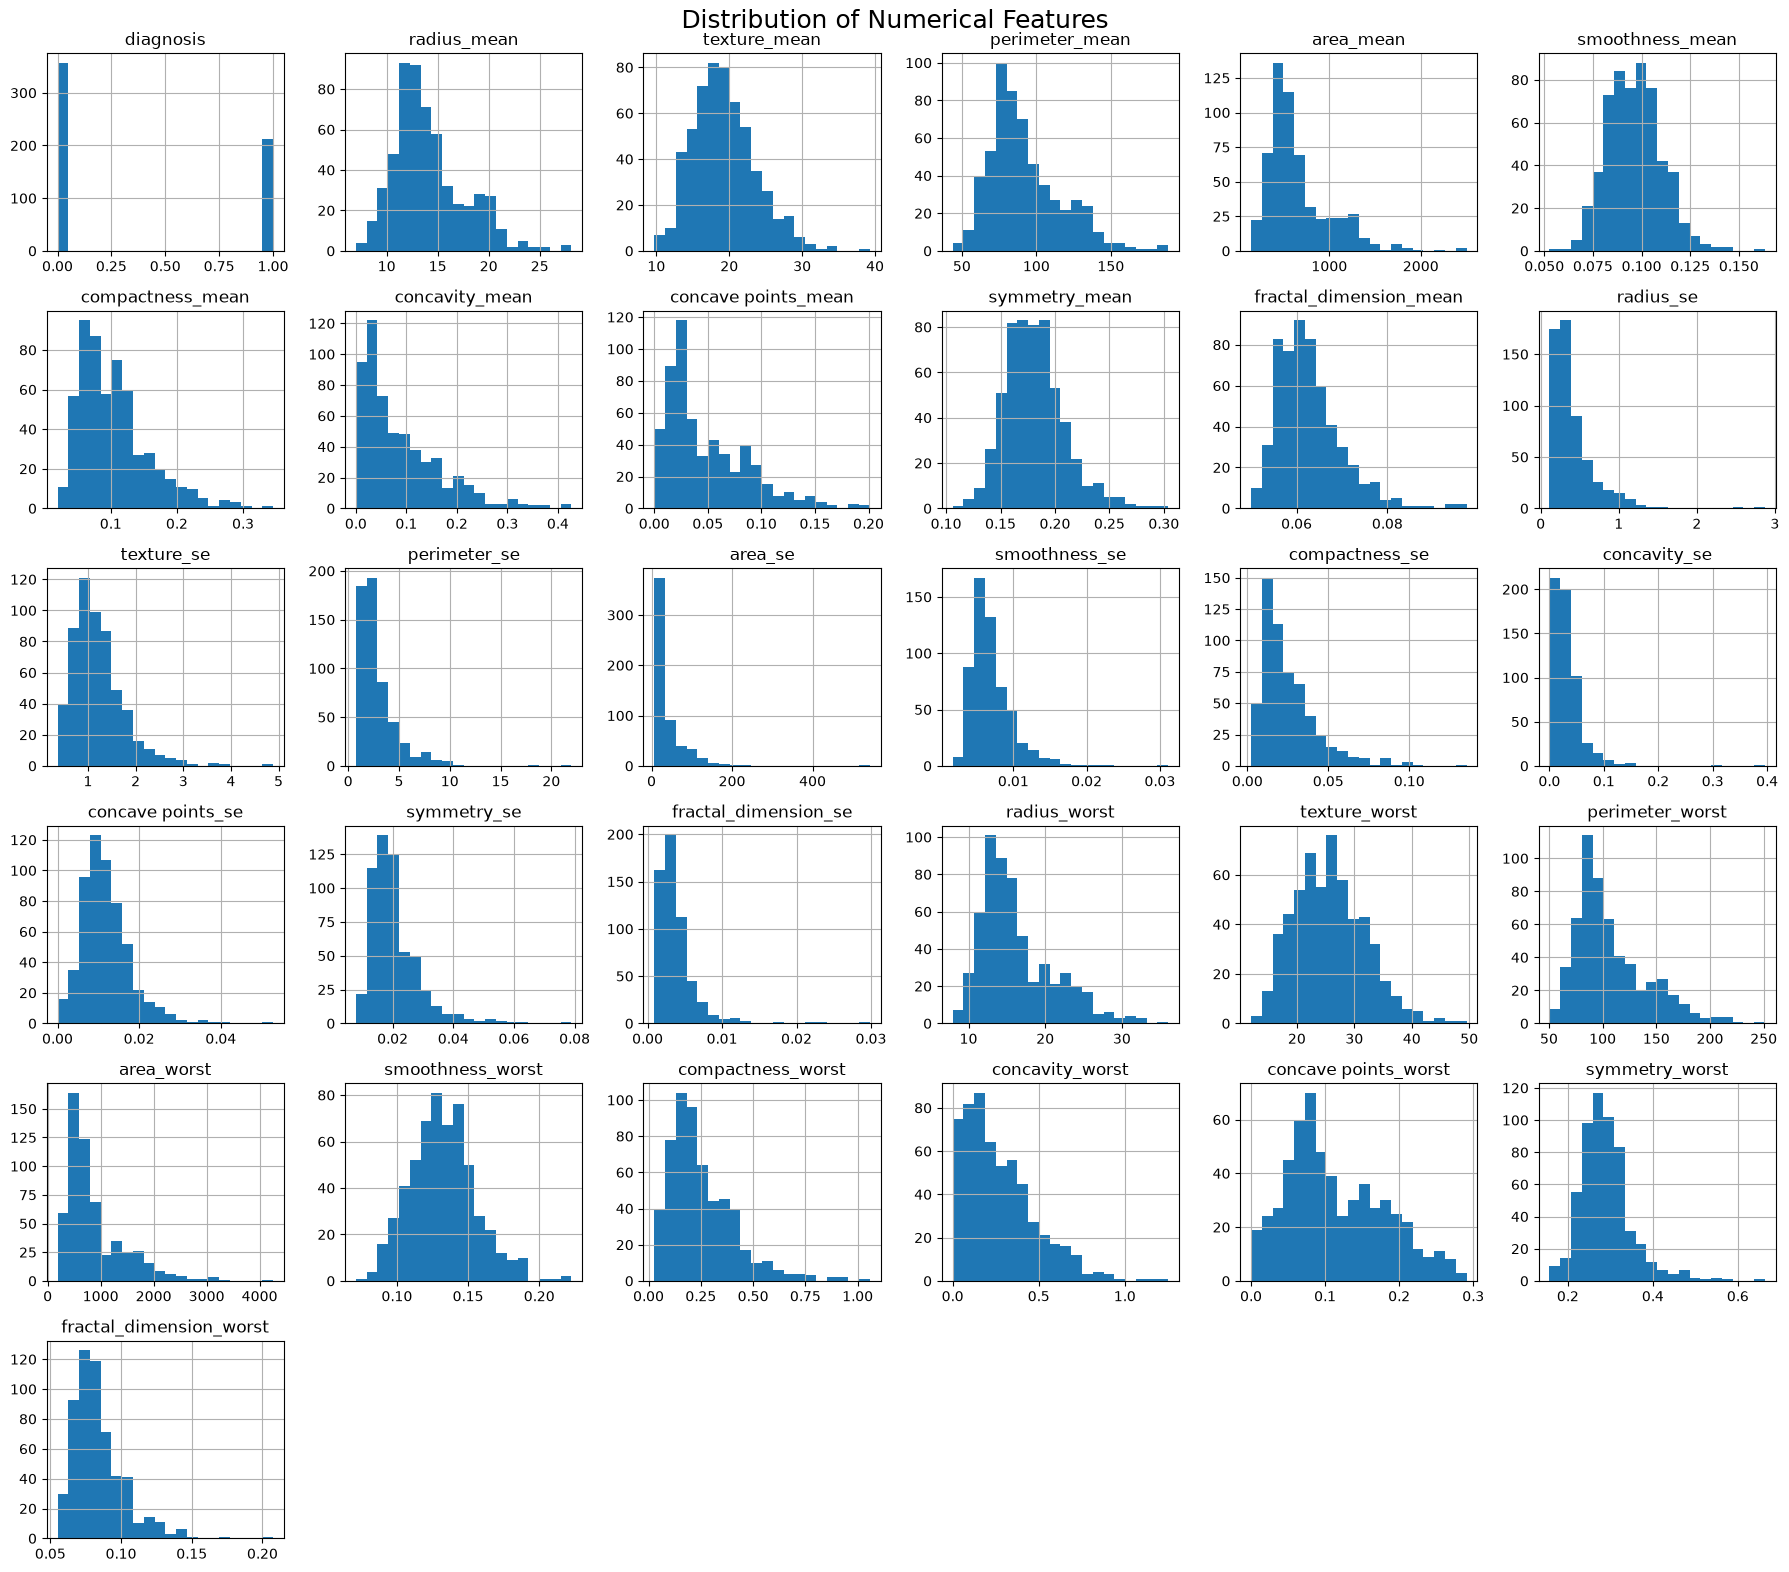

In [10]:
# STEP 5.2: Distribution of Numerical Features

# Plot histograms for all numerical features
df.hist(figsize=(18, 16), bins=20)

plt.suptitle("Distribution of Numerical Features", fontsize=18)

plt.tight_layout()

plt.savefig(
    "../results/histogram.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 5.3 Outlier Detection Using Boxplots

### Objective

Boxplots are used to detect the presence of outliers in important numerical features. Outliers are extreme values that differ significantly from the rest of the observations. In medical datasets, such values may represent genuine patient conditions rather than errors.

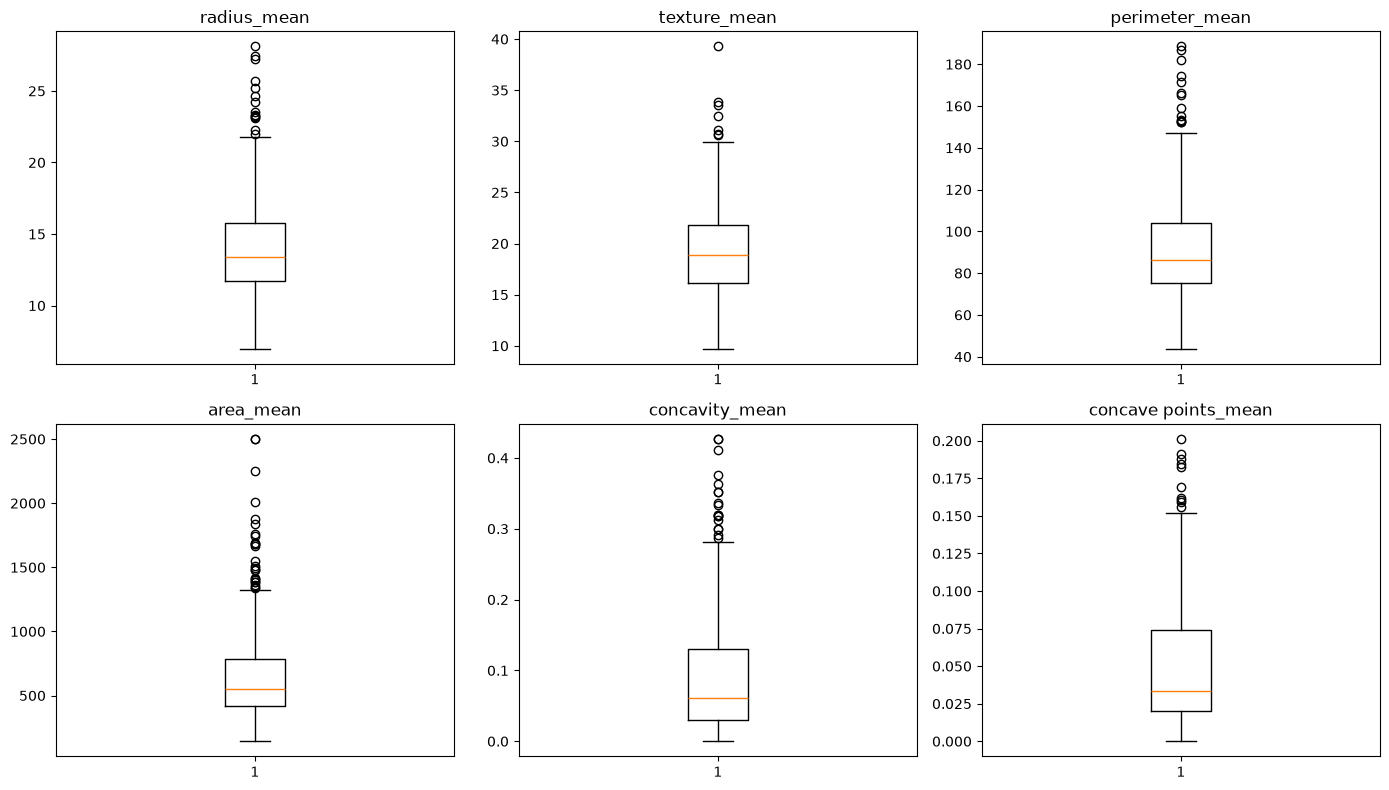

In [11]:
# STEP 5.3: Outlier Detection Using Boxplots

important_features = [
    "radius_mean",
    "texture_mean",
    "perimeter_mean",
    "area_mean",
    "concavity_mean",
    "concave points_mean"
]

plt.figure(figsize=(14,8))

for i, feature in enumerate(important_features):
    plt.subplot(2,3,i+1)
    plt.boxplot(df[feature])
    plt.title(feature)

plt.tight_layout()

plt.savefig(
    "../results/boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [12]:
import matplotlib.pyplot as plt
import numpy as np

In [13]:
import numpy as np

## 5.4 Correlation Heatmap

### Objective

A correlation heatmap is used to measure the relationship between numerical features. Correlation values range from **-1 to +1**, where:

- **+1** indicates a strong positive relationship.
- **0** indicates no relationship.
- **-1** indicates a strong negative relationship.

Understanding feature correlations helps identify important predictors and highly related variables before model training.

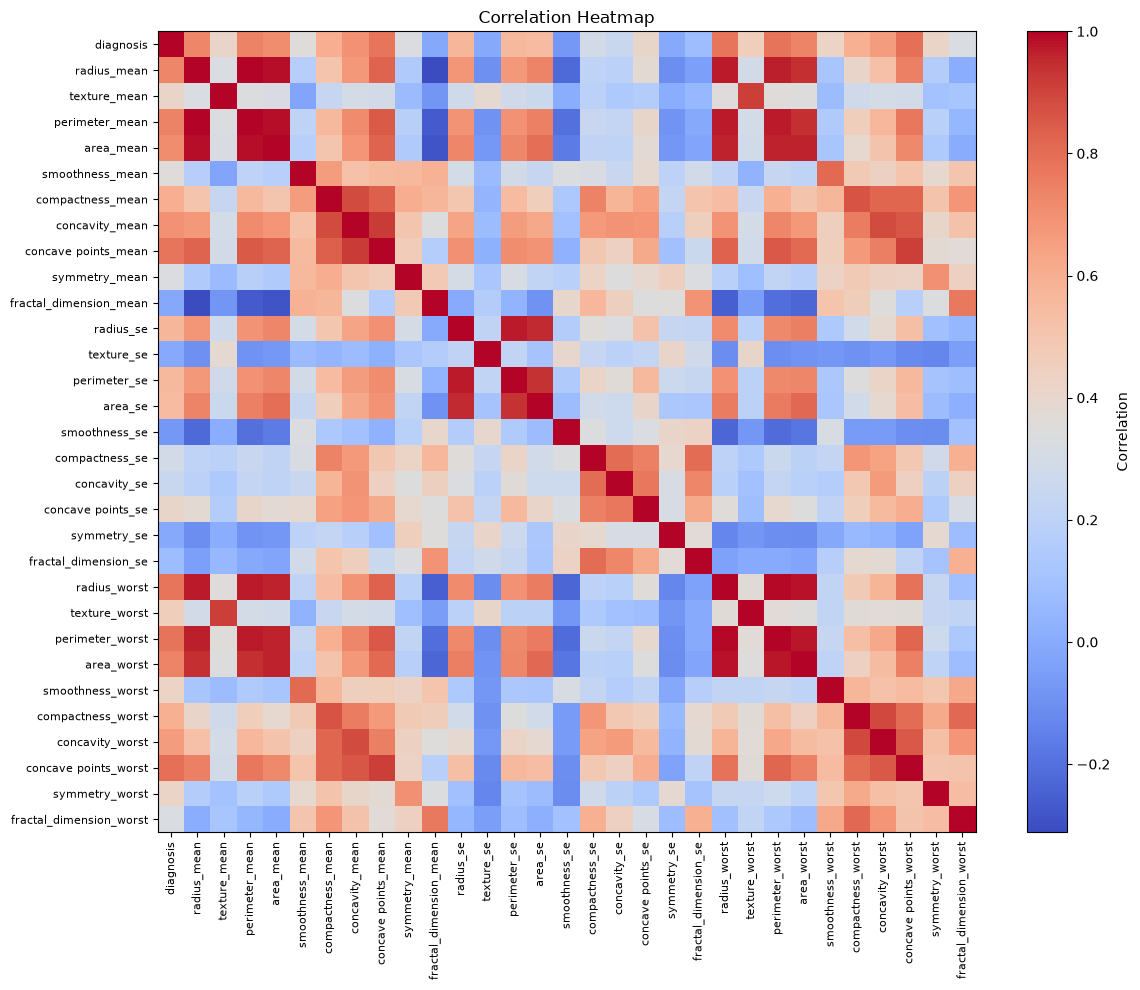

In [14]:
# STEP 5.4: Correlation Heatmap

# Calculate the correlation matrix
correlation_matrix = df.corr()

# Create the heatmap
plt.figure(figsize=(12, 10))

plt.imshow(correlation_matrix, cmap="coolwarm", aspect="auto")

# Add color bar
plt.colorbar(label="Correlation")

# Add labels
plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90,
    fontsize=8
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    fontsize=8
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig(
    "../results/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 6. Machine Learning Model Building

## 6.1 Feature Selection

### Objective

Machine learning models require input variables (features) and an output variable (target). In this project, all numerical tumor characteristics are used as input features, while the **diagnosis** column is selected as the target variable for prediction.

In [15]:
# STEP 6.1: Feature Selection

# Features (Input)
X = df.drop("diagnosis", axis=1)

# Target (Output)
y = df["diagnosis"]

print("Shape of Features (X):", X.shape)
print("Shape of Target (y):", y.shape)

print("\nFirst Five Rows of Features:")
display(X.head())

print("\nFirst Five Target Values:")
display(y.head())

Shape of Features (X): (569, 30)
Shape of Target (y): (569,)

First Five Rows of Features:


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



First Five Target Values:


0    1
1    1
2    1
3    1
4    1
Name: diagnosis, dtype: int64

## 6.2 Train-Test Split

### Objective

The dataset is divided into training and testing sets. The training data is used to teach the machine learning model, while the testing data is used to evaluate its performance on unseen data.

In [16]:
# STEP 6.2: Train-Test Split

from sklearn.model_selection import train_test_split

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Features Shape:", X_train.shape)
print("Testing Features Shape :", X_test.shape)

print()

print("Training Labels Shape :", y_train.shape)
print("Testing Labels Shape  :", y_test.shape)

Training Features Shape: (455, 30)
Testing Features Shape : (114, 30)

Training Labels Shape : (455,)
Testing Labels Shape  : (114,)


## 6.3 Feature Scaling

### Objective

Feature scaling standardizes the numerical features so that they have a similar scale. StandardScaler is used to transform the data by removing the mean and scaling to unit variance. The scaler is fitted only on the training data to prevent data leakage.

In [17]:
# STEP 6.3: Feature Scaling

from sklearn.preprocessing import StandardScaler

# Create scaler object
scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data
X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Completed Successfully!")

print("\nScaled Training Data Shape:", X_train_scaled.shape)
print("Scaled Testing Data Shape :", X_test_scaled.shape)

# Display first five rows of scaled training data
import pandas as pd

scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)

print("\nFirst Five Rows of Scaled Training Data:")
display(scaled_df.head())

Feature Scaling Completed Successfully!

Scaled Training Data Shape: (455, 30)
Scaled Testing Data Shape : (114, 30)

First Five Rows of Scaled Training Data:


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,-1.440753,-0.435319,-1.362085,-1.139118,0.780573,0.718921,2.823135,-0.119150,1.092662,2.458173,...,-1.232861,-0.476309,-1.247920,-0.973968,0.722894,1.186732,4.672828,0.932012,2.097242,1.886450
1,1.974096,1.733026,2.091672,1.851973,1.319843,3.426275,2.013112,2.665032,2.127004,1.558396,...,2.173314,1.311279,2.081617,2.137405,0.761928,3.265601,1.928621,2.698947,1.891161,2.497838
2,-1.399982,-1.249622,-1.345209,-1.109785,-1.332645,-0.307355,-0.365558,-0.696502,1.930333,0.954379,...,-1.295284,-1.040811,-1.245220,-0.999715,-1.438693,-0.548564,-0.644911,-0.970239,0.597602,0.057894
3,-0.981797,1.416222,-0.982587,-0.866944,0.059390,-0.596788,-0.820203,-0.845115,0.313264,0.074041,...,-0.829197,1.593530,-0.873572,-0.742947,0.796624,-0.729392,-0.774950,-0.809483,0.798928,-0.134497
4,-1.117700,-1.010259,-1.125002,-0.965942,1.269511,-0.439002,-0.983341,-0.930600,3.394436,0.950213,...,-1.085129,-1.334616,-1.117138,-0.896549,-0.174876,-0.995079,-1.209146,-1.354582,1.033544,-0.205732


## 6.4 Logistic Regression Model

### Objective

The Logistic Regression algorithm is used to classify tumors as benign or malignant based on the input features. The model is trained using the scaled training data and evaluated using the testing data.

In [18]:
# STEP 6.4: Logistic Regression

from sklearn.linear_model import LogisticRegression

# Create the model
lr_model = LogisticRegression(random_state=42)

# Train the model
lr_model.fit(X_train_scaled, y_train)

print("Logistic Regression Model Trained Successfully!")

Logistic Regression Model Trained Successfully!


## 6.5 Prediction

### Objective

After training, the Logistic Regression model predicts the diagnosis for the testing dataset. These predictions are compared with the actual labels to evaluate the model.

In [19]:
# STEP 6.5: Prediction

# Predict on test data
y_pred_lr = lr_model.predict(X_test_scaled)

print("First 20 Predictions:")
print(y_pred_lr[:20])

print("\nFirst 20 Actual Values:")
print(y_test.values[:20])

First 20 Predictions:
[0 1 1 0 0 1 1 1 0 0 0 1 0 1 0 1 0 0 0 1]

First 20 Actual Values:
[0 1 1 0 0 1 1 1 0 0 0 1 0 1 0 1 0 0 0 1]


## 6.6 Model Evaluation

### Objective

The trained Logistic Regression model is evaluated using Accuracy Score, Confusion Matrix, and Classification Report to measure its prediction performance.

In [20]:
# STEP 6.6: Accuracy Score

from sklearn.metrics import accuracy_score

accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", round(accuracy_lr * 100, 2), "%")

Logistic Regression Accuracy: 97.37 %


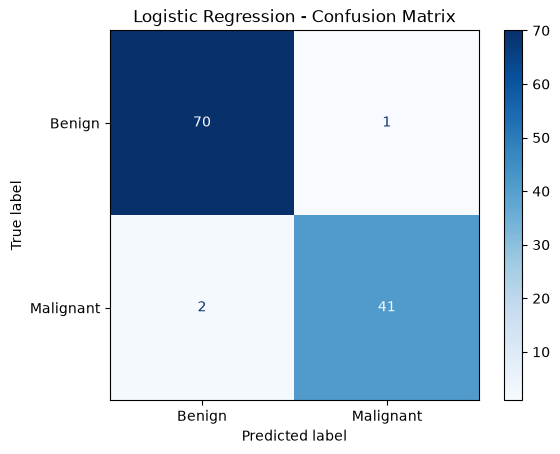

In [21]:
# STEP 6.7: Confusion Matrix

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr,
    display_labels=["Benign", "Malignant"],
    cmap="Blues"
)

plt.title("Logistic Regression - Confusion Matrix")

plt.savefig(
    "../results/logistic_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.show()

In [22]:
# STEP 6.8: Classification Report

from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_lr,
    target_names=["Benign", "Malignant"]
))

              precision    recall  f1-score   support

      Benign       0.97      0.99      0.98        71
   Malignant       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



## 7 Decision Tree Classifier

### 7.1 Objective

The objective of this step is to train a Decision Tree Classifier to predict whether a breast tumor is Benign or Malignant based on the selected features.

A Decision Tree is a supervised machine learning algorithm that makes predictions by learning a series of decision rules from the training data. It divides the dataset into smaller subsets based on the most informative features until a final prediction is reached.

The trained model will then be used to predict the diagnosis of tumors in the testing dataset.

In [23]:
# STEP 7.1: Decision Tree Model

from sklearn.tree import DecisionTreeClassifier

# Create the Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model
dt_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_dt = dt_model.predict(X_test_scaled)

print("Decision Tree Model Trained Successfully!\n")

print("First 20 Predictions:")
print(y_pred_dt[:20])

print("\nFirst 20 Actual Values:")
print(y_test.values[:20])

Decision Tree Model Trained Successfully!

First 20 Predictions:
[0 1 1 0 0 1 1 1 1 0 0 1 0 1 0 1 0 0 0 1]

First 20 Actual Values:
[0 1 1 0 0 1 1 1 0 0 0 1 0 1 0 1 0 0 0 1]


## 7.2 Decision Tree Model Evaluation

### Objective

The objective of this step is to evaluate the performance of the trained Decision Tree model using Accuracy Score, Classification Report, and Confusion Matrix.

These evaluation metrics help measure how accurately the model predicts breast cancer diagnoses and identify any misclassifications made during testing.

In [24]:
# STEP 7.2: Accuracy Score

from sklearn.metrics import accuracy_score

accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", round(accuracy_dt * 100, 2), "%")

Decision Tree Accuracy: 94.74 %


In [25]:
# STEP 7.3: Classification Report

from sklearn.metrics import classification_report

print("Classification Report:\n")

print(classification_report(
    y_test,
    y_pred_dt,
    target_names=["Benign", "Malignant"]
))

Classification Report:

              precision    recall  f1-score   support

      Benign       0.96      0.96      0.96        71
   Malignant       0.93      0.93      0.93        43

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



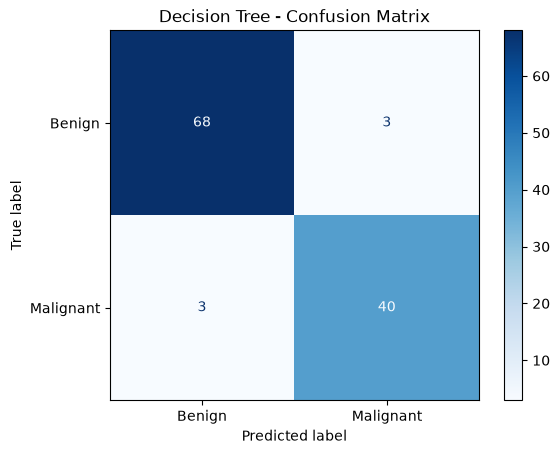

In [26]:
# STEP 7.4: Confusion Matrix

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_dt,
    display_labels=["Benign", "Malignant"],
    cmap="Blues"
)

plt.title("Decision Tree - Confusion Matrix")

plt.savefig(
    "../results/decision_tree_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 8 Random Forest Model

## 8.1 Random Forest Training

### Objective

To train a Random Forest Classifier on the standardized breast cancer dataset and use it to classify tumors as Benign or Malignant.

Random Forest is an ensemble learning algorithm that combines the predictions of multiple Decision Trees to improve classification accuracy and reduce overfitting.

The trained model will be used to predict tumor diagnoses on the testing dataset, and its performance will be evaluated in the following steps.

In [27]:
# STEP 8.1: Random Forest Model

from sklearn.ensemble import RandomForestClassifier

# Create the model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test_scaled)

print("Random Forest Model Trained Successfully!\n")

print("First 20 Predictions:")
print(y_pred_rf[:20])

print("\nFirst 20 Actual Values:")
print(y_test.values[:20])

Random Forest Model Trained Successfully!

First 20 Predictions:
[0 1 1 0 0 1 1 1 1 0 0 1 0 1 0 1 0 0 0 1]

First 20 Actual Values:
[0 1 1 0 0 1 1 1 0 0 0 1 0 1 0 1 0 0 0 1]


## 8.2 Random Forest Model Evaluation

### Objective

To evaluate the performance of the Random Forest model using Accuracy Score, Classification Report, and Confusion Matrix.

The trained Random Forest model is evaluated on the testing dataset to measure its prediction performance.

In [28]:
# STEP 8.2: Accuracy Score

from sklearn.metrics import accuracy_score

accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", round(accuracy_rf * 100, 2), "%")

Random Forest Accuracy: 96.49 %


In [29]:
# STEP 8.3: Classification Report

from sklearn.metrics import classification_report

print("Classification Report:\n")

print(classification_report(
    y_test,
    y_pred_rf,
    target_names=["Benign", "Malignant"]
))

Classification Report:

              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        71
   Malignant       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



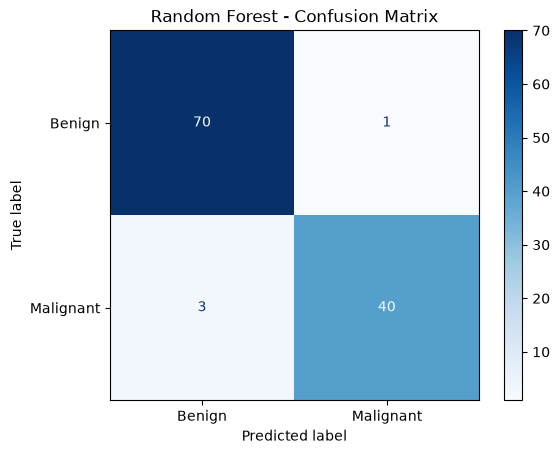

In [30]:
# STEP 8.4: Confusion Matrix

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=["Benign", "Malignant"],
    cmap="Blues"
)

plt.title("Random Forest - Confusion Matrix")

plt.savefig(
    "../results/random_forest_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 9 Support Vector Machine (SVM) Model

## 9.1 SVM Training

### Objective

To train a Support Vector Machine (SVM) classifier on the standardized breast cancer dataset and use it to classify tumors as Benign or Malignant.

Support Vector Machine is a supervised machine learning algorithm that finds the optimal decision boundary (hyperplane) to separate different classes with the maximum possible margin. It is particularly effective for binary classification problems and performs well on high-dimensional datasets.

The trained SVM model will be used to predict tumor diagnoses on the testing dataset, and its performance will be evaluated in the following steps.

In [31]:
# STEP 9.1: Support Vector Machine (SVM) Model

from sklearn.svm import SVC

# Create the model
svm_model = SVC(
    kernel='rbf',
    random_state=42
)

# Train the model
svm_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_svm = svm_model.predict(X_test_scaled)

print("Support Vector Machine Model Trained Successfully!\n")

print("First 20 Predictions:")
print(y_pred_svm[:20])

print("\nFirst 20 Actual Values:")
print(y_test.values[:20])

Support Vector Machine Model Trained Successfully!

First 20 Predictions:
[0 1 1 0 0 1 1 1 0 0 0 1 0 1 0 1 0 0 0 1]

First 20 Actual Values:
[0 1 1 0 0 1 1 1 0 0 0 1 0 1 0 1 0 0 0 1]


## 9.2 Support Vector Machine Model Evaluation

### Objective

To evaluate the performance of the Support Vector Machine (SVM) model using Accuracy Score, Classification Report, and Confusion Matrix.

In [32]:
# STEP 9.2: Accuracy Score

from sklearn.metrics import accuracy_score

accuracy_svm = accuracy_score(y_test, y_pred_svm)

print("Support Vector Machine Accuracy:", round(accuracy_svm * 100, 2), "%")

Support Vector Machine Accuracy: 98.25 %


In [33]:
# STEP 9.3: Classification Report

from sklearn.metrics import classification_report

print("Classification Report:\n")
print(classification_report(y_test, y_pred_svm,
                            target_names=["Benign", "Malignant"]))

Classification Report:

              precision    recall  f1-score   support

      Benign       0.97      1.00      0.99        71
   Malignant       1.00      0.95      0.98        43

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



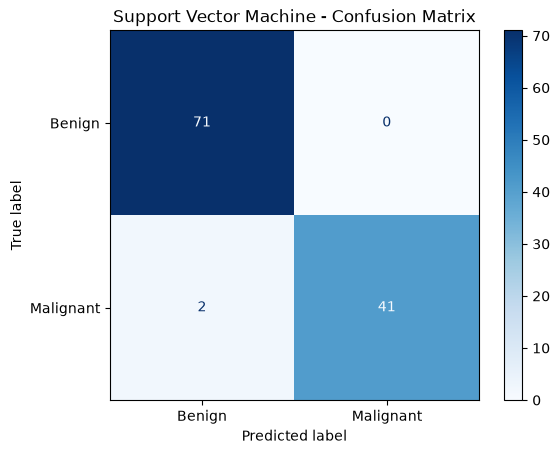

In [34]:
# STEP 9.4: Confusion Matrix

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_svm,
    display_labels=["Benign", "Malignant"],
    cmap="Blues"
)

plt.title("Support Vector Machine - Confusion Matrix")

plt.savefig(
    "../results/svm_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 10 Model Comparison

### Objective

To compare the performance of all machine learning models used in this project and identify the best-performing model for breast cancer prediction.

In [35]:
# STEP 10.1: Accuracy Comparison Table

import pandas as pd

comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Support Vector Machine"
    ],
    "Accuracy (%)": [
        round(accuracy_lr * 100, 2),
        round(accuracy_dt * 100, 2),
        round(accuracy_rf * 100, 2),
        round(accuracy_svm * 100, 2)
    ]
})

comparison_df = comparison_df.sort_values(
    by="Accuracy (%)",
    ascending=False
).reset_index(drop=True)

print("Machine Learning Model Comparison")
display(comparison_df)

Machine Learning Model Comparison


,Model,Accuracy (%)
0,Support Vector Machine,98.25
1,Logistic Regression,97.37
2,Random Forest,96.49
3,Decision Tree,94.74


## 10.2 Accuracy Comparison Chart

### Objective

To visually compare the prediction accuracy of all machine learning models developed in this project.

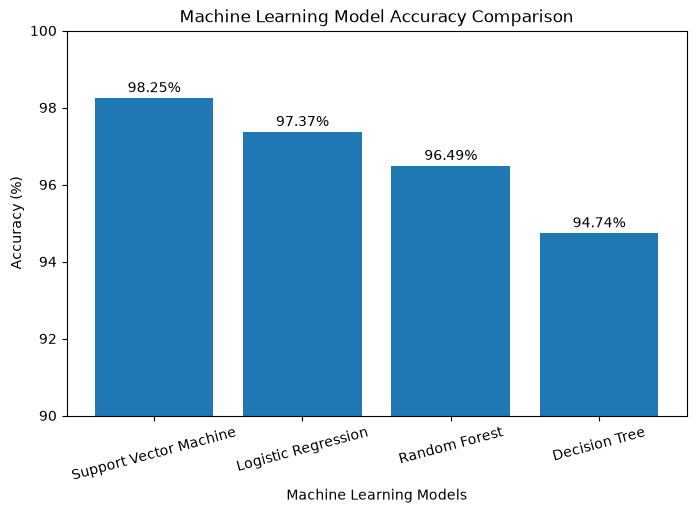

In [36]:
# STEP 10.2: Accuracy Comparison Chart

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy (%)"]
)

plt.title("Machine Learning Model Accuracy Comparison")
plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy (%)")
plt.ylim(90, 100)

plt.xticks(rotation=15)

for index, value in enumerate(comparison_df["Accuracy (%)"]):
    plt.text(index, value + 0.15, f"{value:.2f}%", ha='center')

plt.savefig(
    "../results/accuracy_comparison_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 10.3 Best Model Selection

### Objective

To identify the best-performing machine learning model based on the evaluation results.

In [37]:
# STEP 10.3: Best Model Selection

best_model = comparison_df.iloc[0]

print("Best Performing Machine Learning Model")
print()

print(f"Model Name : {best_model['Model']}")
print(f"Accuracy   : {best_model['Accuracy (%)']} %")

print("\nConclusion:")
print(f"{best_model['Model']} achieved the highest accuracy among all models and is selected as the final prediction model for this project.")

Best Performing Machine Learning Model

Model Name : Support Vector Machine
Accuracy   : 98.25 %

Conclusion:
Support Vector Machine achieved the highest accuracy among all models and is selected as the final prediction model for this project.


In [38]:
import joblib

In [39]:
import joblib
import os

# Create model folder if it doesn't exist
os.makedirs("../model", exist_ok=True)

# Save all trained models
joblib.dump(lr_model, "../model/logistic_regression.pkl")
joblib.dump(dt_model, "../model/decision_tree.pkl")
joblib.dump(rf_model, "../model/random_forest.pkl")
joblib.dump(svm_model, "../model/svm_model.pkl")

print("All trained models have been saved successfully!")

All trained models have been saved successfully!
